# **프로젝트 : 멋진 챗봇 만들기**

**프로젝트 목표**

*   디코딩 만으로 만들어내는 문장 품질은 충분히 확보할 수 있을까?
*   프로젝트에 적합한 정량적 및 정성적 평가 접근으로 모델의 성능 평가가 충분한가?
*   이 프로젝트에 적합한 정량적 지표(BLEU, PERPLEXITY 등)는 무엇일까?



**데이터셋 분석**

*   기본 구조
    *   행 수 : 11,823개
    *   열 수 : 3개
    *   질문-답변쌍 + 3개 클래스 라벨(Q, A, label(정수형 라벨))

*   결측치 / 빈 값 / 중복 여부
    *   결측치 : 0개
    *   빈 값 : 0개
    *   중복 여부
        *   Q-A 쌍 중복 : 73개
        *   질문만 중복 : 161개
        *   답변만 중복 : 4,044개
    *   자주 등장하는 답변
        *   맛있게 드세요. : 22회
        *   제가 있잖아요. : 17회
        *   감기 조심하세요. : 14회
        *   조심하세요. : 14회

*   라벨 분포
    *   0(일상으로 추정) : 5,290개 (44.74%)
    *   1(이별로 추정) : 3,570개 (30.20%)
    *   2(사랑으로 추정) : 2,963개 (25.06%)

*   문장 길이 분석
    *   질문(Q) : 평균 글자 수 12.88자
    *   답변(A) : 평균 글자 수 15.02자

**데이터 전처리 전략**

*   기본 문자열 정제(preprocess_sentence()에서 수행, 문장을 너무 과하게 바꾸지는 않고 노이즈만 줄임)
    *   앞뒤 공백 제거
    *   영문 소문자화
    *   영문, 한글, 숫자, 공백, 주요 특수 문자를 제외하고 불필요한 특수 문자 제거

*   형태소 토큰화(Mecab의 morphs() 사용)
    *   질문과 답변을 전처리한 뒤 Mecab 형태소 단위로 분해(한국어 형태소 기반 토큰화)

*   빈 문장 제거(build_corpus() 안에서 처리)
    *   전처리 후 질문 또는 답변이 비어 있으면 제거
    *   토큰화 후 토큰 개수가 0이면 제거

*   길이 제한(build_corpus()에서 max_len=20 기준으로 처리)
    *   짧은 일상 대화형 문장만 남기도록 길이 필터링

*   중복 제거(build_corpus()에서 수행)
    *   질문과 답변 중복 제거를 각각 별도로 수행

*   타겟 특수 토큰 추가(벡터화 전에 답변(ans_corpus)에 아래 토큰 부여)
    *   start, end 적용
    *   디코더가 어디서 생성 시작하고 끝나는지 알게 함

*   텍스트 시퀀스 벡터화(벡질문과 답변 전체를 합쳐 공유 vocabulary를 만들고 정수 시퀀스로 변환)
    *   Tokenizer(filters="", lower=False, oov_token="unk")
    *   질문과 답변 전체를 같은 사전으로 학습
    *   정수 인덱스로 변환
    *   pad_sequences()로 길이 맞춤


In [1]:
# Colab 필수 패키지 및 Mecab 설치

# - Colab 기본 numpy, pandas, scipy tensorflow 를 강제로 재설치하니까 "numpy.dtype size changed" 같은 ABI 충돌이 발생
# - 기본 과학계산 스택은 그대로 두고 필요한 추가 패키지와 Mecab만 설치

import os
import sys
import subprocess
import importlib.util

def ensure_pip_packages(packages):
    missing = []
    for pkg_name, install_name in packages:
        if importlib.util.find_spec(pkg_name) is None:
            missing.append(install_name)
    if missing:
        print("추가 패키지 설치:", missing)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
    else:
        print("추가 pip 설치 불필요")

ensure_pip_packages([
    ("gensim", "gensim==4.3.3"),
    ("rouge_score", "rouge-score==0.1.2"),
    ("nltk", "nltk==3.9.1"),
    ("konlpy", "konlpy==0.6.0"),
])

if not os.path.exists("/content/Mecab-ko-for-Google-Colab"):
    subprocess.check_call([
        "git", "clone", "-q",
        "https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git",
        "/content/Mecab-ko-for-Google-Colab"
    ])

install_script = "/content/Mecab-ko-for-Google-Colab/install_mecab-ko_on_colab_light_220429.sh"
if os.path.exists(install_script):
    subprocess.check_call(["bash", install_script])
else:
    raise FileNotFoundError(f"Mecab 설치 스크립트를 찾지 못했습니다: {install_script}")

print("설치 셀 완료: Colab 기본 numpy/pandas는 유지했고, 추가 패키지 + Mecab만 설치했습니다.")


추가 pip 설치 불필요
설치 셀 완료: Colab 기본 numpy/pandas는 유지했고, 추가 패키지 + Mecab만 설치했습니다.


In [2]:
import os
import re
import gc
import math
import json
import random
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display

import scipy.linalg
if not hasattr(scipy.linalg, "triu"):
    scipy.linalg.triu = np.triu

try:
    from gensim.models import KeyedVectors, Word2Vec
except Exception as e:
    raise RuntimeError(
        "gensim import 실패입니다. 보통은 설치 셀 실행 누락 또는 런타임 꼬임이 원인입니다.\n"
        f"세부 오류: {repr(e)}"
    )

from konlpy.tag import Mecab
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

warnings.filterwarnings("ignore")
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("현재 단계의 첫 번째 핵심 체크: numpy/pandas import가 정상 완료되었습니다.")


NumPy: 1.26.4
Pandas: 2.2.2
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
현재 단계의 첫 번째 핵심 체크: numpy/pandas import가 정상 완료되었습니다.


**Step 1. 데이터 다운로드 / 로딩**

`ChatbotData.csv` 파일에서 질문(`Q`)과 답변(`A`)을 읽어 `questions`, `answers` 변수에 저장합니다.

In [3]:
def find_file(candidates):
    for candidate in candidates:
        matches = glob.glob(candidate, recursive=True)
        if matches:
            return matches[0]
    return None

csv_path = find_file([
    "/content/ChatbotData.csv",
    "/content/ChatbotData.CSV",
    "/content/chatbotdata.csv",
    "/content/**/*ChatbotData*.csv",
    "/content/**/*.csv",
])

if csv_path is None:
    raise FileNotFoundError("ChatbotData.csv 파일을 /content 에 업로드한 뒤 다시 실행하세요.")

chatbot_df = pd.read_csv(csv_path)
display(chatbot_df.head())

if not {"Q", "A"}.issubset(chatbot_df.columns):
    raise ValueError(f"예상 컬럼(Q, A)이 없습니다. 현재 컬럼: {list(chatbot_df.columns)}")

questions = chatbot_df["Q"].astype(str).tolist()
answers = chatbot_df["A"].astype(str).tolist()

print(f"CSV 경로: {csv_path}")
print(f"질문 수: {len(questions):,}")
print(f"답변 수: {len(answers):,}")

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


CSV 경로: /content/ChatbotData.csv
질문 수: 11,823
답변 수: 11,823


**Step 2. 데이터 정제**

아래 조건을 만족하는 `preprocess_sentence()` 함수를 구현

1. 영문자는 소문자로 변환
2. 영문자/한글/숫자/주요 특수문자 외 제거

In [4]:
def preprocess_sentence(sentence: str) -> str:
    sentence = str(sentence).strip().lower()
    # 영문자/한글/숫자/공백/주요 특수문자만 남김
    sentence = re.sub(r"[^0-9a-z가-힣ㄱ-ㅎㅏ-ㅣ\s\.\,\!\?\:\;\'\"\(\)\[\]\{\}\-\_\~\/%&@#+=*]", " ", sentence)
    # 다중 공백 정리
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

# quick check
samples = [
    "Hello!!! 안녕?? ^_^",
    "오늘 날씨 어때요~~~",
    "I'M FINE :) 123",
]
for s in samples:
    print(s, "->", preprocess_sentence(s))

Hello!!! 안녕?? ^_^ -> hello!!! 안녕?? _
오늘 날씨 어때요~~~ -> 오늘 날씨 어때요~~~
I'M FINE :) 123 -> i'm fine :) 123


**Step 3. 데이터 토큰화**

Mecab 형태소 분석기를 사용해 `build_corpus()` 를 구현

- source 및 target 문장 입력
- 전처리 후 토큰화
- 길이 제한 초과 문장 제거
- source 중복 및 target 중복 각각 제거
- source-target 쌍 정렬 유지

In [5]:
def init_mecab():
    candidate_paths = [
        None,
        "/usr/lib/x86_64-linux-gnu/mecab/dic/mecab-ko-dic",
        "/usr/local/lib/mecab/dic/mecab-ko-dic",
        "/usr/local/share/mecab/dic/mecab-ko-dic",
        "/content/mecab/mecab-ko-dic",
    ]
    errors = []

    for dicpath in candidate_paths:
        try:
            if dicpath is None:
                tagger = Mecab()
                used = "default"
            else:
                tagger = Mecab(dicpath=dicpath)
                used = dicpath
            probe = tagger.morphs("지루하다, 놀러가고 싶어.")
            if not probe:
                raise RuntimeError("빈 토큰 결과")
            print("Mecab 로드 성공:", used)
            return tagger
        except Exception as e:
            errors.append(f"{dicpath or 'default'} -> {repr(e)}")

    raise RuntimeError(
        "Mecab 초기화 실패\n"
        "가능 원인:\n"
        "1) 설치 셀을 건너뛰었거나 중간에 실패함\n"
        "2) 런타임 재연결 후 설치 셀을 다시 실행하지 않음\n"
        "3) 사전 경로가 바뀐 환경\n\n"
        "[시도한 경로별 로그]\n" + "\n".join(errors)
    )

mecab = init_mecab()
print(mecab.morphs("지루하다, 놀러가고 싶어."))


Mecab 로드 성공: default
['지루', '하', '다', ',', '놀', '러', '가', '고', '싶', '어', '.']


In [6]:
def build_corpus(source_data, target_data, tokenizer_fn, max_len=20):
    source_corpus = []
    target_corpus = []

    seen_source = set()
    seen_target = set()

    for src, tgt in zip(source_data, target_data):
        src = preprocess_sentence(src)
        tgt = preprocess_sentence(tgt)

        if not src or not tgt:
            continue

        src_tokens = tokenizer_fn(src)
        tgt_tokens = tokenizer_fn(tgt)

        if len(src_tokens) == 0 or len(tgt_tokens) == 0:
            continue

        if len(src_tokens) > max_len or len(tgt_tokens) > max_len:
            continue

        src_key = tuple(src_tokens)
        tgt_key = tuple(tgt_tokens)

        # 소스는 소스대로, 타겟은 타겟대로 중복 제거
        if src_key in seen_source or tgt_key in seen_target:
            continue

        seen_source.add(src_key)
        seen_target.add(tgt_key)

        source_corpus.append(src_tokens)
        target_corpus.append(tgt_tokens)

    return source_corpus, target_corpus

MAX_LEN = 20
que_corpus, ans_corpus = build_corpus(
    questions,
    answers,
    tokenizer_fn=mecab.morphs,
    max_len=MAX_LEN
)

print(f"정제 후 질문 수: {len(que_corpus):,}")
print(f"정제 후 답변 수: {len(ans_corpus):,}")
print("질문 예시:", que_corpus[0])
print("답변 예시:", ans_corpus[0])

정제 후 질문 수: 7,571
정제 후 답변 수: 7,571
질문 예시: ['12', '시', '땡', '!']
답변 예시: ['하루', '가', '또', '가', '네요', '.']


**Step 4. Augmentation(Lexical Substitution)**

`ko.bin` Word2Vec 모델을 불러와 질문과 답변 양쪽에 lexical substitution을 적용

- `augmentation된 질문 + 원본 답변`
- `원본 질문 + augmentation된 답변`

형태로 결합해 전체 데이터를 약 3배 수준으로 확장

In [14]:
# 한국어 fastText text vector 사용

!wget -O /content/wiki.ko.vec https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.ko.vec

from gensim.models import KeyedVectors

vec_path = "/content/wiki.ko.vec"
wv = KeyedVectors.load_word2vec_format(vec_path, binary=False)

print("로드 성공:", vec_path)
print("vocab size:", len(wv.key_to_index))
print("vector size:", wv.vector_size)

--2026-03-11 02:56:40--  https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.ko.vec
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.81, 13.249.182.39, 13.249.182.33, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.81|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2323010599 (2.2G) [binary/octet-stream]
Saving to: ‘/content/wiki.ko.vec’

/content/wiki.ko.ve 100%[===================>]   2.16G  51.9MB/s    in 45s     

2026-03-11 02:57:25 (48.7 MB/s) - ‘/content/wiki.ko.vec’ saved [2323010599/2323010599]

로드 성공: /content/wiki.ko.vec
vocab size: 879129
vector size: 300


In [16]:
PUNCT_TOKENS = {".", ",", "!", "?", ":", ";", "'", '"', "(", ")", "[", "]", "{", "}", "-", "_", "~", "/", "%", "&", "@", "#", "+", "=", "*"}

def is_replaceable_token(token: str, word_vectors) -> bool:
    if token in PUNCT_TOKENS:
        return False
    if token.isdigit():
        return False
    if len(token.strip()) <= 1:
        return False
    if token.startswith("<") and token.endswith(">"):
        return False
    return token in word_vectors.key_to_index

def lexical_sub(tokens, word_vectors, topn=20, min_similarity=0.55, max_replacements=1):
    tokens = list(tokens)
    candidate_indices = [i for i, tok in enumerate(tokens) if is_replaceable_token(tok, word_vectors)]
    if not candidate_indices:
        return tokens

    random.shuffle(candidate_indices)
    replaced = 0

    for idx in candidate_indices:
        token = tokens[idx]
        try:
            similars = word_vectors.most_similar(token, topn=topn)
        except Exception:
            continue

        valid = [
            w for w, score in similars
            if score >= min_similarity
            and w != token
            and len(w.strip()) > 1
            and w not in PUNCT_TOKENS
        ]
        if not valid:
            continue

        substitute = random.choice(valid)
        tokens[idx] = substitute
        replaced += 1

        if replaced >= max_replacements:
            break

    return tokens

def augment_parallel_corpus(questions_corpus, answers_corpus, word_vectors):
    aug_que = [lexical_sub(q, word_vectors) for q in questions_corpus]
    aug_ans = [lexical_sub(a, word_vectors) for a in answers_corpus]

    # 원본 + (질문만 증강) + (답변만 증강)
    full_que = list(questions_corpus) + list(aug_que) + list(questions_corpus)
    full_ans = list(answers_corpus) + list(answers_corpus) + list(aug_ans)

    return aug_que, aug_ans, full_que, full_ans

aug_que_corpus, aug_ans_corpus, full_que_corpus, full_ans_corpus = augment_parallel_corpus(
    que_corpus, ans_corpus, wv
)

print(f"원본 데이터 수: {len(que_corpus):,}")
print(f"증강 데이터 수: {len(full_que_corpus):,}")
print(f"증강 비율: {len(full_que_corpus)/len(que_corpus):.2f}x")

for i in range(min(3, len(que_corpus))):
    print(f"[원본 질문] {' '.join(que_corpus[i])}")
    print(f"[증강 질문] {' '.join(aug_que_corpus[i])}")
    print(f"[원본 답변] {' '.join(ans_corpus[i])}")
    print(f"[증강 답변] {' '.join(aug_ans_corpus[i])}")
    print("-" * 80)


원본 데이터 수: 7,571
증강 데이터 수: 22,713
증강 비율: 3.00x
[원본 질문] 12 시 땡 !
[증강 질문] 12 시 땡 !
[원본 답변] 하루 가 또 가 네요 .
[증강 답변] 하루 가 또 가 쉽네요 .
--------------------------------------------------------------------------------
[원본 질문] 1 지망 학교 떨어졌 어
[증강 질문] 1 지망 학교앞 떨어졌 어
[원본 답변] 위로 해 드립니다 .
[증강 답변] 위로 해 드립니다만 .
--------------------------------------------------------------------------------
[원본 질문] 3 박 4 일 놀 러 가 고 싶 다
[증강 질문] 3 박 4 일 놀 러 가 고 싶 다
[원본 답변] 여행 은 언제나 좋 죠 .
[증강 답변] 여행 은 친절하며 좋 죠 .
--------------------------------------------------------------------------------


**Step 5. 데이터 벡터화**

*   타겟(answer) 전체에 `<start>`, `<end>` 추가  
*   질문과 답변을 합쳐 공유 vocabulary 구축  
*   벡터화 후 `enc_*`, `dec_*` 구성

In [17]:
START_TOKEN = "<start>"
END_TOKEN = "<end>"
PAD_TOKEN = "<pad>"
OOV_TOKEN = "<unk>"

def detokenize_tokens(tokens):
    text = " ".join(tokens)
    text = re.sub(r"\s+([?.!,;:])", r"\1", text)
    return text.strip()

full_ans_corpus = [[START_TOKEN] + tokens + [END_TOKEN] for tokens in full_ans_corpus]

que_texts = [" ".join(tokens) for tokens in full_que_corpus]
ans_texts = [" ".join(tokens) for tokens in full_ans_corpus]

# 비교표/정성평가용 보기 좋은 텍스트
que_display_texts = [detokenize_tokens(tokens) for tokens in full_que_corpus]
ans_display_texts = [detokenize_tokens(tokens) for tokens in full_ans_corpus]

all_texts_for_vocab = que_texts + ans_texts

keras_tokenizer = tf.keras.preprocessing.text.Tokenizer(
    filters="",
    lower=False,
    oov_token=OOV_TOKEN
)
keras_tokenizer.fit_on_texts(all_texts_for_vocab)

# pad index를 0으로 사용
vocab_size = len(keras_tokenizer.word_index) + 1

enc_all = keras_tokenizer.texts_to_sequences(que_texts)
dec_all = keras_tokenizer.texts_to_sequences(ans_texts)

MAX_SRC_LEN = max(len(x) for x in enc_all)
MAX_TGT_LEN = max(len(x) for x in dec_all)

enc_all = tf.keras.preprocessing.sequence.pad_sequences(
    enc_all, maxlen=MAX_SRC_LEN, padding="post"
)
dec_all = tf.keras.preprocessing.sequence.pad_sequences(
    dec_all, maxlen=MAX_TGT_LEN, padding="post"
)

indices = np.arange(len(enc_all))
train_idx, test_idx = train_test_split(indices, test_size=0.1, random_state=SEED, shuffle=True)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1, random_state=SEED, shuffle=True)

enc_train, dec_train = enc_all[train_idx], dec_all[train_idx]
enc_val, dec_val = enc_all[val_idx], dec_all[val_idx]
enc_test, dec_test = enc_all[test_idx], dec_all[test_idx]

que_train_texts = [que_texts[i] for i in train_idx]
ans_train_texts = [ans_texts[i] for i in train_idx]
que_val_texts = [que_texts[i] for i in val_idx]
ans_val_texts = [ans_texts[i] for i in val_idx]
que_test_texts = [que_texts[i] for i in test_idx]
ans_test_texts = [ans_texts[i] for i in test_idx]

que_train_display = [que_display_texts[i] for i in train_idx]
ans_train_display = [ans_display_texts[i] for i in train_idx]
que_val_display = [que_display_texts[i] for i in val_idx]
ans_val_display = [ans_display_texts[i] for i in val_idx]
que_test_display = [que_display_texts[i] for i in test_idx]
ans_test_display = [ans_display_texts[i] for i in test_idx]

dec_train_in, dec_train_out = dec_train[:, :-1], dec_train[:, 1:]
dec_val_in, dec_val_out = dec_val[:, :-1], dec_val[:, 1:]
dec_test_in, dec_test_out = dec_test[:, :-1], dec_test[:, 1:]

print("vocab_size:", vocab_size)
print("MAX_SRC_LEN:", MAX_SRC_LEN)
print("MAX_TGT_LEN:", MAX_TGT_LEN)
print("enc_train:", enc_train.shape)
print("dec_train:", dec_train.shape)
print("enc_val:", enc_val.shape)
print("enc_test:", enc_test.shape)


vocab_size: 13595
MAX_SRC_LEN: 20
MAX_TGT_LEN: 22
enc_train: (18396, 20)
dec_train: (18396, 22)
enc_val: (2045, 20)
enc_test: (2272, 20)


In [18]:
BATCH_SIZE = 64
BUFFER_SIZE = len(enc_train)

train_ds = tf.data.Dataset.from_tensor_slices(((enc_train, dec_train_in), dec_train_out))
train_ds = train_ds.shuffle(BUFFER_SIZE, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(((enc_val, dec_val_in), dec_val_out))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(((enc_test, dec_test_in), dec_test_out))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

**Step 6. Transformer 모델 정의 및 훈련**

과적합을 줄이기 위해 비교적 작은 하이퍼파라미터를 사용

- `num_layers = 2`
- `d_model = 128`
- `num_heads = 4`
- `dff = 256`
- `dropout = 0.2`
- `batch_size = 64`
- `label smoothing 없이 masked loss`
- `EarlyStopping + ReduceLROnPlateau`

In [19]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        position = np.arange(max_len)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        self.pos_encoding = tf.cast(pe[np.newaxis, ...], tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pos_encoding[:, :seq_len, :]

def create_padding_attention_mask(seq):
    # True/1 means "can attend"
    return tf.not_equal(seq, 0)[:, tf.newaxis, :]  # [B, 1, S]

def create_causal_attention_mask(seq):
    # decoder self-attention용: causal + non-pad
    seq_len = tf.shape(seq)[1]
    causal_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len), dtype=tf.bool), -1, 0)  # [T, T]
    key_mask = tf.not_equal(seq, 0)[:, tf.newaxis, :]   # [B, 1, S]
    query_mask = tf.not_equal(seq, 0)[:, :, tf.newaxis] # [B, T, 1]
    return causal_mask[tf.newaxis, :, :] & key_mask & query_mask  # [B, T, S]

def create_cross_attention_mask(enc_seq, dec_seq):
    # decoder query <-> encoder key attention
    key_mask = tf.not_equal(enc_seq, 0)[:, tf.newaxis, :]   # [B, 1, S]
    query_mask = tf.not_equal(dec_seq, 0)[:, :, tf.newaxis] # [B, T, 1]
    return key_mask & query_mask  # [B, T, S]

class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super().__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation="relu"),
            tf.keras.layers.Dense(d_model),
        ])
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(dropout)
        self.drop2 = tf.keras.layers.Dropout(dropout)

    def call(self, x, training=False, mask=None):
        attn = self.mha(
            query=x, value=x, key=x,
            attention_mask=mask,
            training=training
        )
        attn = self.drop1(attn, training=training)
        out1 = self.norm1(x + attn)

        ffn_out = self.ffn(out1)
        ffn_out = self.drop2(ffn_out, training=training)
        return self.norm2(out1 + ffn_out)

class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super().__init__()
        self.self_mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )
        self.cross_mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation="relu"),
            tf.keras.layers.Dense(d_model),
        ])
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(dropout)
        self.drop2 = tf.keras.layers.Dropout(dropout)
        self.drop3 = tf.keras.layers.Dropout(dropout)

    def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
        attn1 = self.self_mha(
            query=x, value=x, key=x,
            attention_mask=look_ahead_mask,
            training=training
        )
        attn1 = self.drop1(attn1, training=training)
        out1 = self.norm1(x + attn1)

        attn2 = self.cross_mha(
            query=out1, value=enc_output, key=enc_output,
            attention_mask=padding_mask,
            training=training
        )
        attn2 = self.drop2(attn2, training=training)
        out2 = self.norm2(out1 + attn2)

        ffn_out = self.ffn(out2)
        ffn_out = self.drop3(ffn_out, training=training)
        return self.norm3(out2 + ffn_out)

In [20]:
class TransformerChatbot(tf.keras.Model):
    def __init__(self, vocab_size, max_src_len, max_tgt_len,
                 num_layers=2, d_model=128, num_heads=4, dff=256, dropout=0.2):
        super().__init__()
        self.d_model = d_model
        self.token_embedding = tf.keras.layers.Embedding(
            vocab_size, d_model, mask_zero=True, name="shared_embedding"
        )
        self.enc_pos = PositionalEncoding(max_src_len, d_model)
        self.dec_pos = PositionalEncoding(max_tgt_len, d_model)

        self.enc_drop = tf.keras.layers.Dropout(dropout)
        self.dec_drop = tf.keras.layers.Dropout(dropout)

        self.encoder_layers = [
            EncoderLayer(d_model, num_heads, dff, dropout) for _ in range(num_layers)
        ]
        self.decoder_layers = [
            DecoderLayer(d_model, num_heads, dff, dropout) for _ in range(num_layers)
        ]

        self.output_dense = tf.keras.layers.Dense(vocab_size)

    def call(self, inputs, training=False):
        enc_inputs, dec_inputs = inputs

        enc_padding_mask = create_padding_attention_mask(enc_inputs)
        dec_look_ahead_mask = create_causal_attention_mask(dec_inputs)
        cross_padding_mask = create_cross_attention_mask(enc_inputs, dec_inputs)

        enc_x = self.token_embedding(enc_inputs)
        enc_x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        enc_x = self.enc_pos(enc_x)
        enc_x = self.enc_drop(enc_x, training=training)

        for layer in self.encoder_layers:
            enc_x = layer(enc_x, training=training, mask=enc_padding_mask)

        dec_x = self.token_embedding(dec_inputs)
        dec_x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        dec_x = self.dec_pos(dec_x)
        dec_x = self.dec_drop(dec_x, training=training)

        for layer in self.decoder_layers:
            dec_x = layer(
                dec_x, enc_x,
                training=training,
                look_ahead_mask=dec_look_ahead_mask,
                padding_mask=cross_padding_mask
            )

        return self.output_dense(dec_x)

loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none")

def masked_loss(y_true, y_pred):
    loss = loss_object(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss *= mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=-1, output_type=y_true.dtype)
    matches = tf.cast(tf.equal(y_true, y_pred), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    matches *= mask
    return tf.reduce_sum(matches) / tf.reduce_sum(mask)

num_layers = 2
d_model = 128
num_heads = 4
dff = 256
dropout = 0.2
EPOCHS = 30

model = TransformerChatbot(
    vocab_size=vocab_size,
    max_src_len=MAX_SRC_LEN,
    max_tgt_len=MAX_TGT_LEN - 1,
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    dff=dff,
    dropout=dropout
)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

model.compile(
    optimizer=optimizer,
    loss=masked_loss,
    metrics=[masked_accuracy],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_masked_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 67s 106ms/step - loss: 5.7127 - masked_accuracy: 0.2534 - val_loss: 3.6474 - val_masked_accuracy: 0.3975 - learning_rate: 0.0010
Epoch 2/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 3.4564 - masked_accuracy: 0.4063 - val_loss: 3.3568 - val_masked_accuracy: 0.4254 - learning_rate: 0.0010
Epoch 3/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 3.1019 - masked_accuracy: 0.4398 - val_loss: 3.1730 - val_masked_accuracy: 0.4485 - learning_rate: 0.0010
Epoch 4/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 2.8185 - masked_accuracy: 0.4694 - val_loss: 3.0247 - val_masked_accuracy: 0.4682 - learning_rate: 0.0010
Epoch 5/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 2.5868 - masked_accuracy: 0.4992 - val_loss: 2.8795 - val_masked_accuracy: 0.4925 - learning_rate: 0.0010
Epoch 6/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 2.3803 - masked_accuracy: 0.5257 - val_loss: 2.7541 - val_masked_accuracy: 0.5119 - learning_rate: 0.

,loss,masked_accuracy,val_loss,val_masked_accuracy,learning_rate
25,0.728239,0.816818,1.840795,0.731014,0.0005
26,0.710044,0.822242,1.839257,0.731752,0.0005
27,0.692881,0.825592,1.838371,0.738380,0.0005
28,0.680055,0.827811,1.837514,0.739315,0.0005
29,0.668849,0.830083,1.828179,0.744711,0.0005


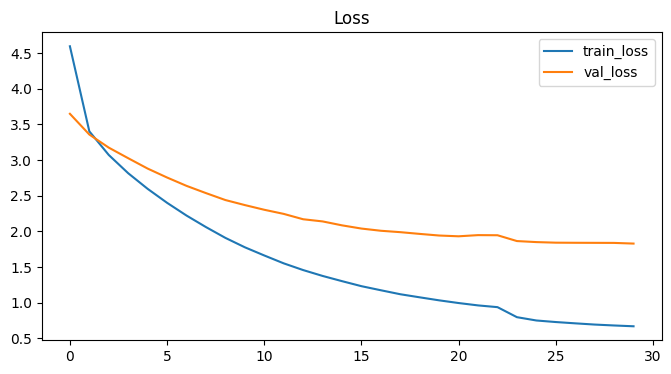

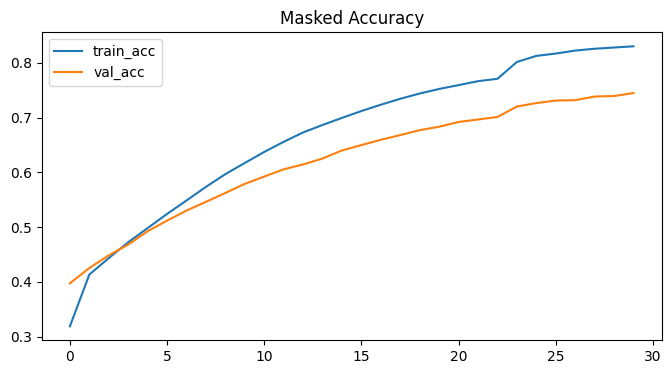

최종 하이퍼파라미터
{'num_layers': 2, 'd_model': 128, 'num_heads': 4, 'dff': 256, 'dropout': 0.2, 'batch_size': 64, 'epochs(max)': 30, 'optimizer': 'Adam(1e-3)', 'max_src_len': 20, 'max_tgt_len': 22, 'vocab_size': 13595}


In [21]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history.history)
display(history_df.tail())

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["masked_accuracy"], label="train_acc")
plt.plot(history.history["val_masked_accuracy"], label="val_acc")
plt.legend()
plt.title("Masked Accuracy")
plt.show()

print("최종 하이퍼파라미터")
print({
    "num_layers": num_layers,
    "d_model": d_model,
    "num_heads": num_heads,
    "dff": dff,
    "dropout": dropout,
    "batch_size": BATCH_SIZE,
    "epochs(max)": EPOCHS,
    "optimizer": "Adam(1e-3)",
    "max_src_len": MAX_SRC_LEN,
    "max_tgt_len": MAX_TGT_LEN,
    "vocab_size": vocab_size,
})

**Step 7. 추론 함수**

학습된 모델로 질문에 대한 답변을 생성

In [22]:
index_word = {v: k for k, v in keras_tokenizer.word_index.items()}
start_id = keras_tokenizer.word_index[START_TOKEN]
end_id = keras_tokenizer.word_index[END_TOKEN]

def tokens_to_text(tokens):
    special = {START_TOKEN, END_TOKEN, PAD_TOKEN, OOV_TOKEN}
    cleaned = [t for t in tokens if t not in special]
    text = " ".join(cleaned)
    text = re.sub(r"\s+([?.!,;:])", r"\1", text)
    return text.strip()

def encode_source_sentence(sentence):
    sentence = preprocess_sentence(sentence)
    sentence = re.sub(r"\s+([?.!,;:])", r"\1", sentence)
    tokens = mecab.morphs(sentence)
    seq = keras_tokenizer.texts_to_sequences([" ".join(tokens)])[0]
    seq = tf.keras.preprocessing.sequence.pad_sequences([seq], maxlen=MAX_SRC_LEN, padding="post")
    return tokens, seq

def _predict_next_logits(enc_input, output_ids):
    dec_input = tf.keras.preprocessing.sequence.pad_sequences(
        [output_ids], maxlen=MAX_TGT_LEN - 1, padding="post"
    )
    logits = model([enc_input, dec_input], training=False).numpy()
    step_index = len(output_ids) - 1
    return logits[0, step_index]

def greedy_decode(sentence, max_decode_len=None):
    if max_decode_len is None:
        max_decode_len = MAX_TGT_LEN - 1

    src_tokens, enc_input = encode_source_sentence(sentence)
    output = [start_id]

    for _ in range(max_decode_len):
        step_logits = _predict_next_logits(enc_input, output)
        next_token = int(np.argmax(step_logits))

        if next_token == 0:
            break

        output.append(next_token)

        if next_token == end_id:
            break

    decoded_tokens = [index_word.get(idx, OOV_TOKEN) for idx in output]
    return {
        "input_tokens": src_tokens,
        "output_tokens": decoded_tokens,
        "response": tokens_to_text(decoded_tokens)
    }

def sample_decode(sentence, temperature=0.9, top_k=10, max_decode_len=None):
    if max_decode_len is None:
        max_decode_len = MAX_TGT_LEN - 1

    src_tokens, enc_input = encode_source_sentence(sentence)
    output = [start_id]

    for _ in range(max_decode_len):
        pred = _predict_next_logits(enc_input, output)
        pred = pred / max(float(temperature), 1e-6)

        vocab_n = len(pred)
        k = max(1, min(int(top_k), vocab_n))

        if k == 1:
            next_token = int(np.argmax(pred))
        elif k >= vocab_n:
            top_indices = np.argsort(pred)[-k:]
            top_logits = pred[top_indices]
            probs = tf.nn.softmax(top_logits).numpy()
            probs = probs / probs.sum()
            next_token = int(np.random.choice(top_indices, p=probs))
        else:
            top_indices = np.argpartition(pred, -k)[-k:]
            top_logits = pred[top_indices]
            probs = tf.nn.softmax(top_logits).numpy()
            probs = probs / probs.sum()
            next_token = int(np.random.choice(top_indices, p=probs))

        if next_token == 0:
            break

        output.append(next_token)

        if next_token == end_id:
            break

    decoded_tokens = [index_word.get(idx, OOV_TOKEN) for idx in output]
    return {
        "input_tokens": src_tokens,
        "output_tokens": decoded_tokens,
        "response": tokens_to_text(decoded_tokens)
    }


In [23]:
sample_prompts = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]

print("[Greedy Decoding 결과]")
for s in sample_prompts:
    result = greedy_decode(s)
    print(f"Q: {s}")
    print(f"A: {result['response']}")
    print("-" * 80)

print("\n[Top-k Sampling 결과]")
for s in sample_prompts:
    result = sample_decode(s, temperature=0.9, top_k=10)
    print(f"Q: {s}")
    print(f"A: {result['response']}")
    print("-" * 80)

[Greedy Decoding 결과]
Q: 지루하다, 놀러가고 싶어.
A: 잘 먹 고 잘 해 보 세요.
--------------------------------------------------------------------------------
Q: 오늘 일찍 일어났더니 피곤하다.
A: 정신 적 으로 육체 적 으로 힘들 고 듣 세요.
--------------------------------------------------------------------------------
Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 떨리 겠 어요.
--------------------------------------------------------------------------------
Q: 집에 있는다는 소리야.
A: 데려가 주 세요.
--------------------------------------------------------------------------------

[Top-k Sampling 결과]
Q: 지루하다, 놀러가고 싶어.
A: 잘 먹 고 잘 해 보 세요.
--------------------------------------------------------------------------------
Q: 오늘 일찍 일어났더니 피곤하다.
A: 정신 차리 는 게 쉽 지 않 죠.
--------------------------------------------------------------------------------
Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 떨리 겠 어요.
--------------------------------------------------------------------------------
Q: 집에 있는다는 소리야.
A: 데려가 주 세요.
--------------------------------------------------------------------------------


**Step 7. 성능 측정**

- BLEU Score
- ROUGE-L
- Distinct-1 / Distinct-2
- 테스트 샘플 20개 question / reference / prediction 비교표
- 비교표는 화면에 출력하고 CSV로도 저장합니다.


In [24]:
def strip_special_tokens(text):
    tokens = text.split()
    special = {START_TOKEN, END_TOKEN, PAD_TOKEN, OOV_TOKEN}
    tokens = [t for t in tokens if t not in special]
    return tokens

def calculate_bleu(questions_texts, reference_answers_texts, decode_fn, max_samples=300):
    refs = []
    hyps = []

    sample_n = min(max_samples, len(questions_texts))
    for q_text, ref_text in zip(questions_texts[:sample_n], reference_answers_texts[:sample_n]):
        pred = decode_fn(q_text)["response"]
        ref_tokens = strip_special_tokens(ref_text)
        hyp_tokens = pred.split()

        if len(hyp_tokens) == 0:
            hyp_tokens = [""]

        refs.append([ref_tokens])
        hyps.append(hyp_tokens)

    bleu = corpus_bleu(
        refs,
        hyps,
        smoothing_function=SmoothingFunction().method4
    )
    return bleu, refs, hyps

def calculate_rouge_l(reference_answers_texts, predicted_answers, max_samples=300):
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)
    scores = []

    sample_n = min(max_samples, len(reference_answers_texts))
    for ref_text, pred_text in zip(reference_answers_texts[:sample_n], predicted_answers[:sample_n]):
        ref = " ".join(strip_special_tokens(ref_text))
        pred = pred_text.strip()
        score = scorer.score(ref, pred)["rougeL"].fmeasure
        scores.append(score)

    return float(np.mean(scores)) if scores else 0.0

def distinct_n(texts, n=1):
    total_ngrams = []
    for text in texts:
        tokens = text.split()
        if len(tokens) < n:
            continue
        ngrams = zip(*[tokens[i:] for i in range(n)])
        total_ngrams.extend(list(ngrams))
    if len(total_ngrams) == 0:
        return 0.0
    return len(set(total_ngrams)) / len(total_ngrams)

# 정량평가는 사람이 읽는 자연문장 질문을 입력으로 사용
eval_questions = que_test_display if "que_test_display" in globals() else [
    re.sub(r"\s+([?.!,;:])", r"\1", q) for q in que_test_texts
]

test_predictions = []
eval_size = min(300, len(eval_questions))

for q_text in eval_questions[:eval_size]:
    pred = greedy_decode(q_text)["response"]
    test_predictions.append(pred)

bleu_score, refs, hyps = calculate_bleu(eval_questions, ans_test_texts, greedy_decode, max_samples=eval_size)
rouge_l = calculate_rouge_l(ans_test_texts, test_predictions, max_samples=eval_size)
distinct_1 = distinct_n(test_predictions, n=1)
distinct_2 = distinct_n(test_predictions, n=2)

metrics_df = pd.DataFrame([{
    "BLEU": bleu_score,
    "ROUGE-L": rouge_l,
    "Distinct-1": distinct_1,
    "Distinct-2": distinct_2,
    "Eval Samples": eval_size
}])

display(metrics_df)


,BLEU,ROUGE-L,Distinct-1,Distinct-2,Eval Samples
0,0.27994,0.0,0.280984,0.652713,300


In [25]:
def detokenize_text(text):
    tokens = strip_special_tokens(text)
    text = " ".join(tokens)
    text = re.sub(r"\s+([?.!,;:])", r"\1", text)
    return text.strip()

sample_count = min(20, len(que_test_texts))
sample_indices = np.random.default_rng(SEED).choice(len(que_test_texts), size=sample_count, replace=False)

qualitative_samples = []
for rank, idx in enumerate(sample_indices, start=1):
    question_text = que_test_display[idx] if "que_test_display" in globals() else detokenize_text(que_test_texts[idx])
    reference_text = ans_test_display[idx] if "ans_test_display" in globals() else detokenize_text(ans_test_texts[idx])
    pred = greedy_decode(question_text)["response"]

    qualitative_samples.append({
        "sample_id": rank,
        "question": question_text,
        "reference": reference_text,
        "prediction": pred
    })

qual_df = pd.DataFrame(qualitative_samples)
display(qual_df)

os.makedirs("/content/chatbot_artifacts", exist_ok=True)
qual_csv_path = "/content/chatbot_artifacts/test_samples_20_comparison.csv"
qual_df.to_csv(qual_csv_path, index=False, encoding="utf-8-sig")
print("비교표 저장 완료:", qual_csv_path)


,sample_id,question,reference,prediction
0,1,꿈 을 안 꿀 수 있 다면,<start> 다른 생각 을 해 보 는 건 좋을듯합니다 요. <end>,꿈 은 현실 을 거 예요.
1,2,아침 에 일어났 다가 또 잤 어,<start> 피곤해 했 나 봐요. <end>,피곤 했 나 봐요.
2,3,내 가 말 하 면 왜 맹비난 만 할까,<start> 성장 을 위한 비판 의 말 로 받아들여 보 세요. <end>,다른 사람 들 이 원 하 는 걸 어 보 세요.
3,4,다리 떠 는 거 말 들 음,<start> 남 에게 피해아동의 만 주 지 않 는다면 괜찮 아요. <end>,의식 하 는 거 라 믿 어요.
4,5,내 가 오랫동안 좋 아 하 던 사람 이 날 몰라.,<start> 자신 의 존재 를 알리 는 게 우선 이 겠 네요. <end>,자신 의 존재 를 알리 는 게 우선 이 겠 네요.
5,6,전 여친 카톡 탈퇴 재 가입 한 거 같 은데,<start> 관심 을 거두긴 세요. <end>,관심 을 거두 세요.
6,7,핑계,<start> 개로만 핑계 겠 죠. <end>,안 해도 귀여워 요.
7,8,파마 하 면 어울릴까,<start> 한 번 해 보 세요. <end>,한 번 해 보 말하세요.
8,9,헤어진 여자 친구 연락,<start> 허연 한가 봐요. <end>,연락 을 해 보 세요.
9,10,오랜만 에 결혼 한 친구 만나 고 왔 는데.,<start> 소식도 을 들 었 나 봐요. <end>,오랜만 에 생각 해 보 세요.


비교표 저장 완료: /content/chatbot_artifacts/test_samples_20_comparison.csv


**Step 8. 모델 저장**

학습이 끝난 뒤 가중치, 토크나이저, 그리고 테스트 샘플 20개 비교표 CSV를 저장


In [26]:
save_dir = "/content/chatbot_artifacts"
os.makedirs(save_dir, exist_ok=True)

model.save_weights(os.path.join(save_dir, "transformer_chatbot.weights.h5"))

tokenizer_info = {
    "word_index": keras_tokenizer.word_index,
    "index_word": {str(k): v for k, v in index_word.items()},
    "config": {
        "MAX_SRC_LEN": int(MAX_SRC_LEN),
        "MAX_TGT_LEN": int(MAX_TGT_LEN),
        "vocab_size": int(vocab_size),
        "START_TOKEN": START_TOKEN,
        "END_TOKEN": END_TOKEN,
        "OOV_TOKEN": OOV_TOKEN,
        "num_layers": num_layers,
        "d_model": d_model,
        "num_heads": num_heads,
        "dff": dff,
        "dropout": dropout,
        "batch_size": BATCH_SIZE,
        "seed": SEED,
    }
}

with open(os.path.join(save_dir, "tokenizer_config.json"), "w", encoding="utf-8") as f:
    json.dump(tokenizer_info, f, ensure_ascii=False, indent=2)

print("저장 완료:", save_dir)
print(os.listdir(save_dir))

저장 완료: /content/chatbot_artifacts
['test_samples_20_comparison.csv', 'transformer_chatbot.weights.h5', 'tokenizer_config.json']


**정량적인 결과 분석**

*   학습 데이터에서는 masked accuracy가 0.83 수준까지 상승했고 검증 데이터에서도 0.74 수준의 정확도를 보여 기본적인 문장 생성 패턴은 안정적으로 학습한 것으로 판단
*   BLEU Score(정답과 매치되는 표현이 얼마나 많은지 평가하는 지표)는 0.27994로, 기준 답변과 완전히 동일하지는 않더라도 일정 수준의 어휘적 유사성을 보이는 응답을 생성했음을 보여줌
*   ROUGE-L(문장 전체의 핵심 흐름이 얼마나 비슷한지 평가하는 지표)이 0.0으로 나타난 것은 모델 성능이 전혀 없다고 보기보다는 평가 구현 과정에서 토큰화, 띄어쓰기, 문장 정렬 방식의 차이가 반영되지 않았을 가능성 존재
*   Distinct-1과 Distinct-2에서 각각 0.281)과 (0.653)이 출력되었는데 모델이 완전히 동일한 답변만 반복하는 수준은 아니라는 점을 보여줌


**정성적인 결과 분석**

*   출력된 예문을 바탕으로 "간만에 여자친구랑 데이트 하기로 했어"에 대해 "떨리겠어요"라고 응답한 경우는 상황과 감정 흐름에 비교적 잘 부합하였으나 "지루하다, 놀러가고 싶어"에 대해 "잘 먹고 잘 해 보세요"처럼 질문과 의미 연결이 약하거나 다소 엉뚱한 응답도 확인되었음. 이를 통하여 모델이 감정형이나 상투형 응답은 어느 정도 학습했지만, 입력 의미를 정교하게 반영하는 능력은 아직 제한적이라고 판단됨
*   테스트 샘플 20개 비교표를 통해 확인한 결과, 모델은 일부 질문에 대해 정답 문장과 정확히 일치하지 않더라도 의미상 유사한 반응을 생성하는 경우가 있었지만 여러 사례에서 입력 문맥과 직접적인 관련성이 약한 일반적 위로 문장이나 상투적 표현으로 치우치는 경향도 나타남



**프로젝트의 한계점 및 보완점**

*   Mecab 토큰을 단순 결합해 출력하면서 "떨리 겠 어요", "잘 먹 고"같은 어색한 결과가 발생(띄어쓰기 복원 문제 발생)
*   ROUGE-L이 0.0으로 출력되어 성능이 0이라기보다 토큰 분리나 복원에서부터 문제가 발생한 것으로 판단
*   greedy decoding만 사용한 결과로 상투적 답변이 많아져 학습에 시간이 오래 걸리더라도 beam search를 추가하는 것이 필요하다고 사료됨
*   lexical substitution 중심으로 데이터를 증강하였으나 역번역 등의 방법도 가능할 것임




**회고**

*   Transformer 모델은 짧은 대화 데이터에서도 기본적인 응답 생성은 가능했음
*   처음에는 모델 구조 구현 자체에 초점을 두었지만 실제 프로젝트 수행 중에는 Mecab 토큰화 이후의 복원 문제와 augmentation을 통한 품질 향상 등 데이터 처리 단계가 결과 품질에 매우 큰 영향을 준다는 점을 배웠음

